In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Creamos un dataset simulando Códigos de actividad de red utilizados para la detección de intrusiones
data = {
    'sesion_id':['SID_0000' + str(i % 10 + 1) for i in range(10)],
    'network_packet_size': [599, 472, 629, 804, 453, 453, 815, 653, 406, 608],
    'protocolo': ['TCP','TCP', 'TCP', 'UDP', 'TCP', 'UDP', 'ICMP', 'TCP', 'TCP', 'UDP'],
    'login_attempts': [4, 3, 3, 4, 5, 5, 4, 3, 2, 6],
    'session_duration': [4929832634426560, 15579964611204300, 7504426166420740, 6012488351708320, 5325408884201410, 3804715502453130, 7281071646972350, 125999060098958, 5425588952208970, 5319441066211390],
    'encryption_used': ['DES', 'DES', 'DES', 'DES', 'AES', 'AES', 'AES', 'DES', 'None', 'None'],
    'failed_logins': [1, 0, 2, 0, 1, 2, 1, 3, 0, 1],
    'browser_type': ['Edge', 'Firefox', 'Chrome', 'Unknown', 'Firefox', 'Chrome', 'Chrome', 'Chrome', 'Chrome', 'Chrome']
}
# Creamos el DataFrame
df = pd.DataFrame(data)
print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

1. Explorando el DataFrame:
   sesion_id  network_packet_size protocolo  login_attempts  \
0  SID_00001                  599       TCP               4   
1  SID_00002                  472       TCP               3   
2  SID_00003                  629       TCP               3   
3  SID_00004                  804       UDP               4   
4  SID_00005                  453       TCP               5   

    session_duration encryption_used  failed_logins browser_type  
0   4929832634426560             DES              1         Edge  
1  15579964611204300             DES              0      Firefox  
2   7504426166420740             DES              2       Chrome  
3   6012488351708320             DES              0      Unknown  
4   5325408884201410             AES              1      Firefox  

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------  

In [20]:
# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['browser_type'])
# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['sesion_id', 'network_packet_size', 'protocolo', 'browser_type']])



2. Selección de datos:

Selección de una columna (Serie):
0       Edge
1    Firefox
2     Chrome
3    Unknown
4    Firefox
5     Chrome
6     Chrome
7     Chrome
8     Chrome
9     Chrome
Name: browser_type, dtype: object

Selección de múltiples columnas (DataFrame):
    sesion_id  network_packet_size protocolo browser_type
0   SID_00001                  599       TCP         Edge
1   SID_00002                  472       TCP      Firefox
2   SID_00003                  629       TCP       Chrome
3   SID_00004                  804       UDP      Unknown
4   SID_00005                  453       TCP      Firefox
5   SID_00006                  453       UDP       Chrome
6   SID_00007                  815      ICMP       Chrome
7   SID_00008                  653       TCP       Chrome
8   SID_00009                  406       TCP       Chrome
9  SID_000010                  608       UDP       Chrome


In [ ]:
# 3. Selección de datos
# Selección por índice con iloc
print("\nSelección por índice con iloc (primeras 3 filas, columnas 0 y 3):")
print(df.iloc[0:3, [0, 3]])
# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde encriptación utilizada  es 'AES'):")
print(df.loc[df['encryption_used'] == 'AES', ['network_packet_size', 'protocolo', 'browser_type']])


Selección por índice con iloc (primeras 3 filas, columnas 0 y 3):
   sesion_id  login_attempts
0  SID_00001               4
1  SID_00002               3
2  SID_00003               3

Selección por nombre con loc (filas donde encriptación utilizada  es 'AES'):
   network_packet_size protocolo browser_type
4                  453       TCP      Firefox
5                  453       UDP       Chrome
6                  815      ICMP       Chrome


In [ ]:
# 4. Filtrado de datos
print("\n3. Filtrado de datos mayor o igual a 2:")
# Filtrar login fallidos
login_fallidos = df[df['failed_logins'] >= 2]
print("\nlogin_fallidos:")
print(login_fallidos[['network_packet_size', 'protocolo', 'browser_type']])
# Filtrado de intentos de conexión 
intentos_logueo = df[(df['login_attempts'] >= 4) & (df['protocolo'] == 'ICMP')]
print("\nIntentos de logueo en protocolo ICMP:")
print(intentos_logueo)


3. Filtrado de datos:

login_fallidos:
   network_packet_size protocolo browser_type
2                  629       TCP       Chrome
5                  453       UDP       Chrome
7                  653       TCP       Chrome

Intentos de logueo en protocolo ICMP:
   sesion_id  network_packet_size protocolo  login_attempts  session_duration  \
6  SID_00007                  815      ICMP               4  7281071646972350   

  encryption_used  failed_logins browser_type  
6             AES              1       Chrome  


In [45]:
# 5. Estadisticas
print("\n5. Estadisticas:")
# Agrupar por protocolo y contar conexiones
conteo_por_protocolo = df.groupby('protocolo').size()
print("\nConteo de conexiones por protocolo:")
print(conteo_por_protocolo)
# Estadísticas por protocolo
stats_por_protocolo = df.groupby('protocolo')['network_packet_size'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes enviados por protocolo:")
print(stats_por_protocolo)


5. Estadisticas:

Conteo de conexiones por protocolo:
protocolo
ICMP    1
TCP     6
UDP     3
dtype: int64

Estadísticas de bytes enviados por protocolo:
           count        mean  min  max
protocolo                             
ICMP           1  815.000000  815  815
TCP            6  535.333333  406  653
UDP            3  621.666667  453  804


/tmp/ipykernel_1925/1745266493.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(data=df,x=c,hue='failed_logins',palette=colors)


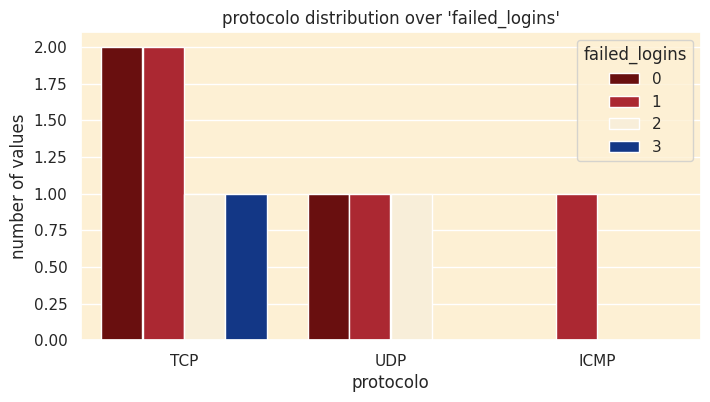

/tmp/ipykernel_1925/1745266493.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(data=df,x=c,hue='failed_logins',palette=colors)


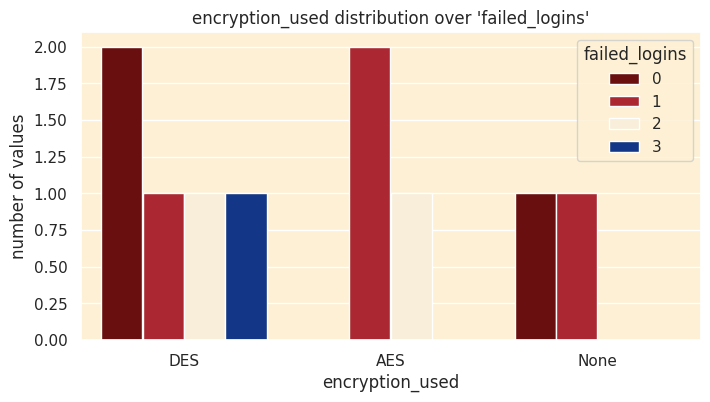

/tmp/ipykernel_1925/1745266493.py:8: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(data=df,x=c,hue='failed_logins',palette=colors)


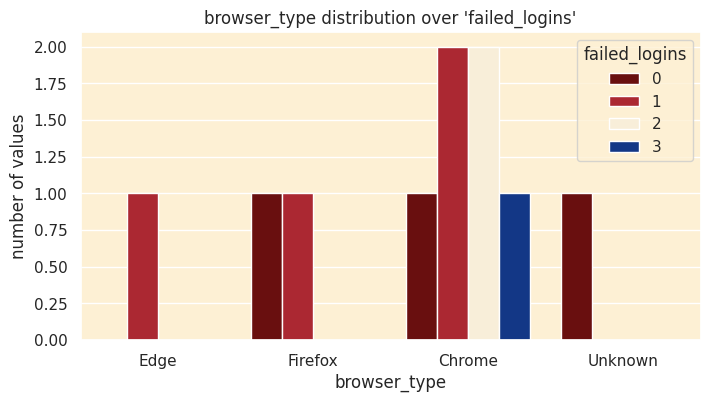

In [44]:
import seaborn as sns
colors = ['#780000', '#c1121f', '#fdf0d4', '#003099', '#669bbc']
sns.set_theme(style="darkgrid", rc={'axes.facecolor': colors[2]})
obj_col = df.select_dtypes(include="object")
obj_col.drop(columns=["sesion_id"],inplace=True)
for c in obj_col.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=c,hue='failed_logins',palette=colors)
    plt.xlabel(c)
    plt.ylabel("number of values")
    plt.title(f"{c} distribution over 'failed_logins'")
    plt.show()